# Section 12: Validate the Variants in trans results

This notebook documents whether the colocalized variants in the target gene show any signals in our trans finemapping results. 

The steps are:

1. Load the trans finemapping flatten table. 
2. Load the colocalized variants from Section 2.
3. Check their PIP in the corresponding files.

To apply this to other genes, simply use `Ctrl+F` to replace `BIN1` with the gene of interest, or change the gene name in the block below.

In [1]:
library(tidyverse)
library(data.table)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




The following object is masked from ‘package:purrr’:

    transpose




In [2]:
source('../../codes/utilis.R')

gene_name = 'BIN1'
tar_gene_info <- get_gene_info(gene_name = gene_name)
gene_id <- tar_gene_info$gene_info$region_id



Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [3]:
gene_id

[1] "ENSG00000136717"

## flatten table

In [4]:
# get variants in coloc set with AD cohorts
coloc_res <- readRDS("/data/interactive_analysis/aw3600//Figure_2b/cb_AD_res_study_May22.rds")
coloc_res_extracted <- coloc_res %>% filter(gene_ID == gene_id)
#coloc_res_extracted
coloc_vars <- coloc_res_extracted %>% pull(variant_ID)
coloc_vars
# var_df <- readRDS(paste0(gene_name, "_colocboost_res.rds"))
# coloc_vars <- var_df %>% filter(str_detect(`colocalized phenotypes`, 'AD')) %>% pull(`colocalized variants`) %>% str_split(., ";", simplify = T) %>% as.character

[1] "chr2:127090354:G:A"    "chr2:127107524:G:A"    "chr2:127128582:C:T"   
[4] "chr2:127128657:C:T"    "chr2:127128795:T:C"    "chr2:127128970:AAAG:A"
[7] "chr2:127131181:A:C"    "chr2:127135234:C:T"    "chr2:127135234:C:T"

In [5]:
coloc_res %>% filter(gene_ID == gene_id)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cos_ID,vcp,cos_npc,min_npc_outcome,coef,study,contexts
<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
2,127090352,127090354,A,G,chr2:127090354:G:A,ENSG00000136717,DLPFC_lf2_sQTL_chr2:127054012:127057472:clu_25426_-:PR:ENSG00000136717; DLPFC_lf2_sQTL_chr2:127064018:127068923:clu_25427_-:PR:ENSG00000136717; Kellis_Oli_ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos7:y47_y53_y70_y92,0.6740388,0.8779,0.4279,-0.00992963303635514;0.00495819513469408;0.0337067190323246;0.00168061892757102,AD_Kunkle_Stage1_2019,"Oli_Kellis_eQTL, ROSMAP_DLPFC_sQTL"
2,127107522,127107524,A,G,chr2:127107524:G:A,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.1415014,0.5469,0.5288,0.0151996491433663;0.000266821047287484,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128580,127128582,T,C,chr2:127128582:C:T,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2115699,0.5469,0.5288,0.00466197335113811;0.0023605432837051,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128655,127128657,T,C,chr2:127128657:C:T,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2039479,0.5469,0.5288,0.00466197335113811;0.00224784352180708,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128793,127128795,C,T,chr2:127128795:T:C,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2156539,0.5469,0.5288,0.00466197335113811;0.00242149294523967,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128968,127128970,A,AAAG,chr2:127128970:AAAG:A,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2171041,0.5469,0.5288,0.00466197335113811;0.0024432296937597,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127131179,127131181,C,A,chr2:127131181:A:C,ENSG00000136717,DLPFC_lf2_sQTL_chr2:127054012:127057472:clu_25426_-:PR:ENSG00000136717; DLPFC_lf2_sQTL_chr2:127064018:127068923:clu_25427_-:PR:ENSG00000136717; Kellis_Oli_ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos7:y47_y53_y70_y92,0.3135734,0.8779,0.4279,-0.0243955528654206;0.024436280202189;0.000253146654462241;0.00617598128379704,AD_Kunkle_Stage1_2019,"Oli_Kellis_eQTL, ROSMAP_DLPFC_sQTL"
2,127135232,127135234,T,C,chr2:127135234:C:T,ENSG00000136717,DeJager_Mic_ENSG00000136717; Kellis_Mic_ENSG00000136717; PCC_lf2_sQTL_chr2:127054012:127057472:clu_20108_-:PR:ENSG00000136717; AD_Bellenguez,ENSG00000136717:cos3:y62_y68_y78_y92,0.9999594,1.0000,0.3671,0.201020938922382;0.179757869547616;-0.0265068720189766;0.0200019593024786,AD_Bellenguez,"Mic_DeJager_eQTL, Mic_Kellis_eQTL, ROSMAP_PCC_sQTL"
2,127135232,127135234,T,C,chr2:127135234:C:T,ENSG00000136717,DeJager_Mic_ENSG00000136717; Kellis_Mic_ENSG00000136717; PCC_lf2_sQTL_chr2:127054012:127057472:clu_20108_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos4:y62_y68_y78_y92,0.9995707,1.0000,0.3920,0.202764493500552;0.179597509728822;-0.029025003679824;0.0194487168455163,AD_Kunkle_Stage1_2019,"Mic_DeJager_eQTL, Mic_Kellis_eQTL, ROSMAP_PCC_sQTL"


In [6]:
coloc_res_extracted

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cos_ID,vcp,cos_npc,min_npc_outcome,coef,study,contexts
<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
2,127090352,127090354,A,G,chr2:127090354:G:A,ENSG00000136717,DLPFC_lf2_sQTL_chr2:127054012:127057472:clu_25426_-:PR:ENSG00000136717; DLPFC_lf2_sQTL_chr2:127064018:127068923:clu_25427_-:PR:ENSG00000136717; Kellis_Oli_ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos7:y47_y53_y70_y92,0.6740388,0.8779,0.4279,-0.00992963303635514;0.00495819513469408;0.0337067190323246;0.00168061892757102,AD_Kunkle_Stage1_2019,"Oli_Kellis_eQTL, ROSMAP_DLPFC_sQTL"
2,127107522,127107524,A,G,chr2:127107524:G:A,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.1415014,0.5469,0.5288,0.0151996491433663;0.000266821047287484,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128580,127128582,T,C,chr2:127128582:C:T,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2115699,0.5469,0.5288,0.00466197335113811;0.0023605432837051,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128655,127128657,T,C,chr2:127128657:C:T,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2039479,0.5469,0.5288,0.00466197335113811;0.00224784352180708,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128793,127128795,C,T,chr2:127128795:T:C,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2156539,0.5469,0.5288,0.00466197335113811;0.00242149294523967,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127128968,127128970,A,AAAG,chr2:127128970:AAAG:A,ENSG00000136717,AC_lf2_sQTL_chr2:127051243:127057472:clu_21774_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos9:y6_y92,0.2171041,0.5469,0.5288,0.00466197335113811;0.0024432296937597,AD_Kunkle_Stage1_2019,ROSMAP_AC_sQTL
2,127131179,127131181,C,A,chr2:127131181:A:C,ENSG00000136717,DLPFC_lf2_sQTL_chr2:127054012:127057472:clu_25426_-:PR:ENSG00000136717; DLPFC_lf2_sQTL_chr2:127064018:127068923:clu_25427_-:PR:ENSG00000136717; Kellis_Oli_ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos7:y47_y53_y70_y92,0.3135734,0.8779,0.4279,-0.0243955528654206;0.024436280202189;0.000253146654462241;0.00617598128379704,AD_Kunkle_Stage1_2019,"Oli_Kellis_eQTL, ROSMAP_DLPFC_sQTL"
2,127135232,127135234,T,C,chr2:127135234:C:T,ENSG00000136717,DeJager_Mic_ENSG00000136717; Kellis_Mic_ENSG00000136717; PCC_lf2_sQTL_chr2:127054012:127057472:clu_20108_-:PR:ENSG00000136717; AD_Bellenguez,ENSG00000136717:cos3:y62_y68_y78_y92,0.9999594,1.0000,0.3671,0.201020938922382;0.179757869547616;-0.0265068720189766;0.0200019593024786,AD_Bellenguez,"Mic_DeJager_eQTL, Mic_Kellis_eQTL, ROSMAP_PCC_sQTL"
2,127135232,127135234,T,C,chr2:127135234:C:T,ENSG00000136717,DeJager_Mic_ENSG00000136717; Kellis_Mic_ENSG00000136717; PCC_lf2_sQTL_chr2:127054012:127057472:clu_20108_-:PR:ENSG00000136717; AD_Kunkle_Stage1_2019,ENSG00000136717:cos4:y62_y68_y78_y92,0.9995707,1.0000,0.3920,0.202764493500552;0.179597509728822;-0.029025003679824;0.0194487168455163,AD_Kunkle_Stage1_2019,"Mic_DeJager_eQTL, Mic_Kellis_eQTL, ROSMAP_PCC_sQTL"


In [7]:
gene_ref <- fread('/data/resource/references/Homo_sapiens.GRCh38.103.chr.reformatted.collapse_only.gene.region_list')

In [8]:
head(gene_ref)

#chr,start,end,gene_id,gene_name
<chr>,<int>,<int>,<chr>,<chr>
chr1,11868,11869,ENSG00000223972,DDX11L1
chr1,17435,17436,ENSG00000278267,MIR6859-1
chr1,29553,29554,ENSG00000243485,MIR1302-2HG
chr1,29569,29570,ENSG00000227232,WASH7P
chr1,30365,30366,ENSG00000284332,MIR1302-2
chr1,36080,36081,ENSG00000237613,FAM138A


In [9]:
all_trans_export = read_delim("/data/analysis_result/trans/FunGen_xQTL.trans.exported.toploci.bed.gz")

Rows: 3321438 Columns: 20


── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (7): a1, a2, variant_ID, gene_ID, event_ID, resource, cs_id
dbl (13): #chr, start, end, MAF, betahat, sebetahat, z, cs_coverage_0.95, cs...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
head(all_trans_export)

#chr,start,end,a1,a2,variant_ID,MAF,betahat,sebetahat,z,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,resource,p,cs_id
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1049885,1049886,T,C,chr1:1049886:C:T,0.46749226,0.1327816,0.02681009,4.952674,chr1_16103_2888443,Knight_eQTL_ENSG00000239381,0,0,0,0.03547114,0.1233230,Knight_eQTL,7.320041e-07,chr1_16103_2888443_Knight_eQTL_ENSG00000239381_0
1,1065529,1065530,T,C,chr1:1065530:C:T,0.06006006,0.3837264,0.07654434,5.013125,chr1_16103_2888443,Knight_eQTL_ENSG00000166439,0,2,2,0.80734554,0.3312900,Knight_eQTL,5.355300e-07,chr1_16103_2888443_Knight_eQTL_ENSG00000166439_0
1,1072051,1072052,A,G,chr1:1072052:G:A,0.43361582,0.1232127,0.02506218,4.916280,chr1_16103_2888443,Knight_eQTL_ENSG00000239381,0,0,0,0.03007148,0.1141156,Knight_eQTL,8.820415e-07,chr1_16103_2888443_Knight_eQTL_ENSG00000239381_0
1,1073853,1073854,C,T,chr1:1073854:T:C,0.42514124,0.1283476,0.02494646,5.144924,chr1_16103_2888443,Knight_eQTL_ENSG00000239381,0,1,1,0.08267034,0.1219261,Knight_eQTL,2.676292e-07,chr1_16103_2888443_Knight_eQTL_ENSG00000239381_0
1,1075336,1075337,T,C,chr1:1075337:C:T,0.41525424,0.1310906,0.02500006,5.243611,chr1_16103_2888443,Knight_eQTL_ENSG00000239381,0,1,1,0.12634756,0.1250085,Knight_eQTL,1.574641e-07,chr1_16103_2888443_Knight_eQTL_ENSG00000239381_0
1,1079455,1079456,G,A,chr1:1079456:A:G,0.42655367,0.1260471,0.02515046,5.011719,chr1_16103_2888443,Knight_eQTL_ENSG00000239381,0,0,0,0.04475009,0.1182110,Knight_eQTL,5.394599e-07,chr1_16103_2888443_Knight_eQTL_ENSG00000239381_0


In [11]:
#all_trans_export %>% saveRDS("/data/interactive_analysis/aw3600//xqtl-paper/all_twas_export.rds")

In [12]:
all_trans_export %>% filter(variant_ID %in% coloc_vars) %>% 
      mutate(
          gene_id = str_extract(event_ID, 'ENSG[0-9]+')# Extract gene_id from study
#          position = str_split(variant_ID, ":", simplify = TRUE)[,2] %>% as.numeric  # Extract position from variant_id        
      )

#chr,start,end,a1,a2,variant_ID,MAF,betahat,sebetahat,z,⋯,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,resource,p,cs_id,gene_id
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
2,127135233,127135234,T,C,chr2:127135234:C:T,0.4021480,0.2595905,0.04820448,5.385195,⋯,ROSMAP_DeJager_eQTL_Inh_ENSG00000230124,0,1,1,0.74765772,0.2336705,ROSMAP_DeJager_eQTL_Inh,7.236611e-08,chr2_125689597_127728648_ROSMAP_DeJager_eQTL_Inh_ENSG00000230124_0,ENSG00000230124
2,127107523,127107524,A,G,chr2:127107524:G:A,0.3385167,0.2970648,0.06246815,4.755460,⋯,ROSMAP_DeJager_eQTL_OPC_ENSG00000126602,0,0,0,0.05955655,0.2827654,ROSMAP_DeJager_eQTL_OPC,1.979951e-06,chr2_125689597_127728648_ROSMAP_DeJager_eQTL_OPC_ENSG00000126602_0,ENSG00000126602
2,127128581,127128582,T,C,chr2:127128582:C:T,0.2799043,0.3264557,0.06778319,4.816175,⋯,ROSMAP_DeJager_eQTL_OPC_ENSG00000126602,0,0,0,0.07916513,0.3112246,ROSMAP_DeJager_eQTL_OPC,1.463366e-06,chr2_125689597_127728648_ROSMAP_DeJager_eQTL_OPC_ENSG00000126602_0,ENSG00000126602
2,127128656,127128657,T,C,chr2:127128657:C:T,0.2799043,0.3264557,0.06778319,4.816175,⋯,ROSMAP_DeJager_eQTL_OPC_ENSG00000126602,0,0,0,0.07916513,0.3112246,ROSMAP_DeJager_eQTL_OPC,1.463366e-06,chr2_125689597_127728648_ROSMAP_DeJager_eQTL_OPC_ENSG00000126602_0,ENSG00000126602
2,127128794,127128795,C,T,chr2:127128795:T:C,0.2799043,0.3264557,0.06778319,4.816175,⋯,ROSMAP_DeJager_eQTL_OPC_ENSG00000126602,0,0,0,0.07916513,0.3112246,ROSMAP_DeJager_eQTL_OPC,1.463366e-06,chr2_125689597_127728648_ROSMAP_DeJager_eQTL_OPC_ENSG00000126602_0,ENSG00000126602
2,127128969,127128970,A,AAAG,chr2:127128970:AAAG:A,0.2799043,0.3264557,0.06778319,4.816175,⋯,ROSMAP_DeJager_eQTL_OPC_ENSG00000126602,0,0,0,0.07916513,0.3112246,ROSMAP_DeJager_eQTL_OPC,1.463366e-06,chr2_125689597_127728648_ROSMAP_DeJager_eQTL_OPC_ENSG00000126602_0,ENSG00000126602
2,127090353,127090354,A,G,chr2:127090354:G:A,0.3146186,0.1513506,0.03012723,5.023714,⋯,STARNET_eQTL_ENSG00000234608,0,0,0,0.25664286,0.1246408,STARNET_eQTL,5.068173e-07,chr2_125689597_127728648_STARNET_eQTL_ENSG00000234608_0,ENSG00000234608
2,127107523,127107524,A,G,chr2:127107524:G:A,0.2773438,-0.4306535,0.08077476,-5.331536,⋯,MSBB_eQTL_BM44_ENSG00000080031,0,1,1,0.54880752,-0.4152830,MSBB_eQTL_BM44,9.738563e-08,chr2_125689597_127728648_MSBB_eQTL_BM44_ENSG00000080031_0,ENSG00000080031
2,127128581,127128582,T,C,chr2:127128582:C:T,0.2285156,-0.4251669,0.08984481,-4.732236,⋯,MSBB_eQTL_BM44_ENSG00000080031,0,0,0,0.04465844,-0.4069226,MSBB_eQTL_BM44,2.220596e-06,chr2_125689597_127728648_MSBB_eQTL_BM44_ENSG00000080031_0,ENSG00000080031


In [13]:
flat_var <- tryCatch(
  {
   all_trans_export %>% filter(variant_ID %in% coloc_vars) %>% 
      mutate(
          gene_id = str_extract(event_ID, 'ENSG[0-9]+'),# Extract gene_id from study
          position = str_split(variant_ID, ":", simplify = TRUE)[,2] %>% as.numeric  # Extract position from variant_id        
      ) %>%
      merge(., gene_ref, by = 'gene_id') %>%  # Merge with gene_ref by gene_id
      arrange(desc(as.numeric(PIP))) %>%  # Arrange by pip in descending order
      mutate(gene_name = factor(gene_name, levels = unique(gene_name))) # Convert gene_name to factor with unique levels,
  }, error = function(e) NULL  # Return NULL in case of error
)      

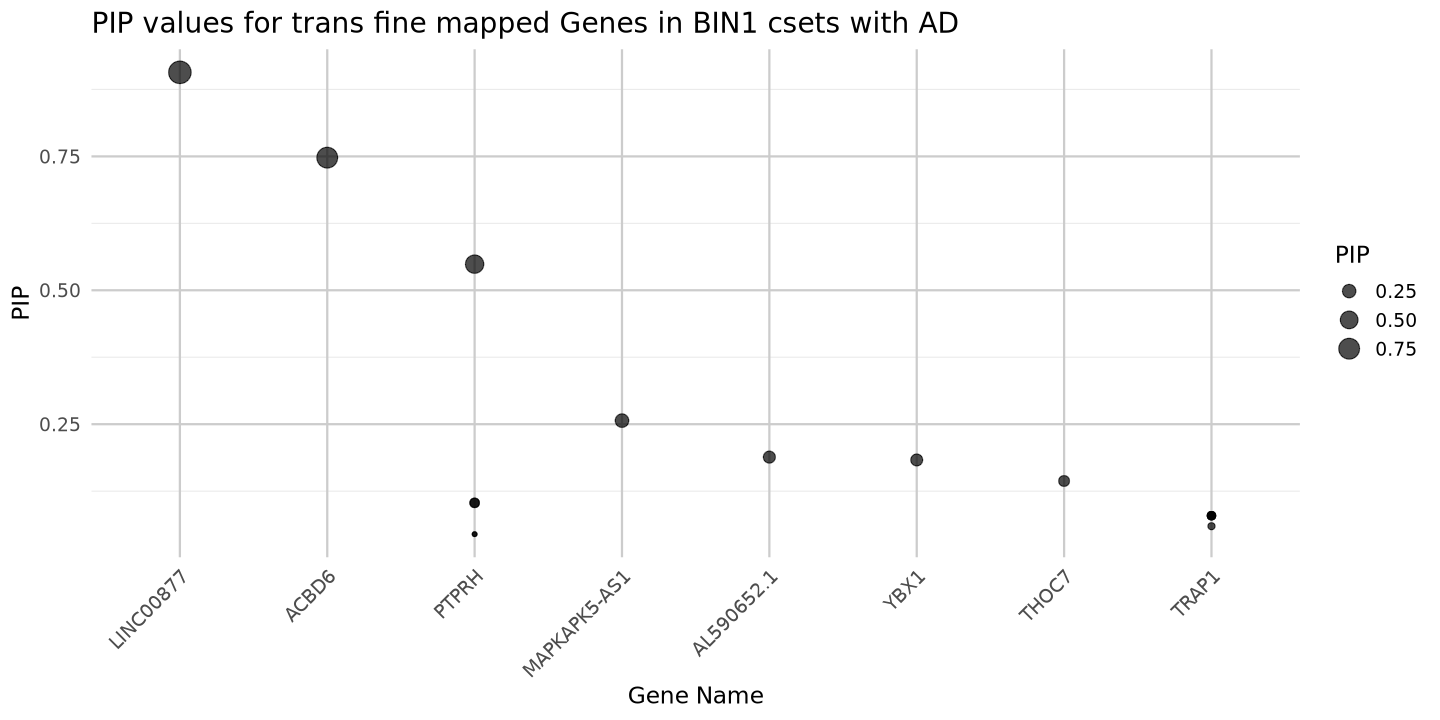

In [14]:
options(repr.plot.width=12, repr.plot.height=6)
if(!is.null(flat_var)){
   p =  ggplot(flat_var, aes(x = gene_name, y = PIP, size = PIP)) +
      geom_point(alpha = 0.7) +
      labs(title = paste0("PIP values for trans fine mapped Genes in ", gene_name ," csets with AD"),
           x = "Gene Name",
           y = "PIP",
           size = "PIP",
           color = "CS Coverage 0.95 Min Corr") +
      theme_minimal(base_size = 14) +
      theme(panel.background = element_blank(),
            panel.grid.major = element_line(color = "grey80"),
            legend.position = NULL,
            axis.text.x = element_text(angle = 45, hjust = 1))  
      # scale_color_manual(values = colorRampPalette(brewer.pal(8, "Set1"))(length(unique(flat_var$gene_name))))
    ggsave(paste0('plots/BIN1/sec12.trans_fine_mapping_',gene_name,'.pdf'),p, height = 5, width = 8)
    p
    } else{
    message('There are no detectable trans signals for ', gene_name)
}